In [18]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [19]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

Device: cuda


In [20]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
print('Seed set.')

Seed set.


In [ ]:
# CONFIG 

TRAIN_DATA_ROOT = os.path.expanduser('~/Desktop/george/rocks_spectral_224')
NEW_DATA_ROOT   = os.path.expanduser('~/for_test_data_spectral_224')
NEWSAMP_ROOT    = os.path.expanduser('~/20260511_New_Granite-Limestone-Sandstone_224')
OOD_FOLDER      = os.path.join(NEW_DATA_ROOT, 'Dunite-Ecologite_2Rocks_1-83Hz')

RESULTS_DIR = 'results_balanced_multisource'
DIR_TRAIN   = os.path.join(RESULTS_DIR, 'training')
DIR_EVAL    = os.path.join(RESULTS_DIR, 'evaluation')
DIR_INF     = os.path.join(RESULTS_DIR, 'inference')
for d in [RESULTS_DIR, DIR_TRAIN, DIR_EVAL, DIR_INF]:
    os.makedirs(d, exist_ok=True)

MODEL_183 = os.path.join(RESULTS_DIR, 'balanced_multisource_1-83Hz.pth')
MODEL_510 = os.path.join(RESULTS_DIR, 'balanced_multisource_5-10Hz.pth')

ARCH        = 'resnet18'
EPOCHS      = 20
LR          = 1e-4
WEIGHT_DECAY = 1e-4
BATCH_SIZE  = 64
TEST_SPLIT  = 0.25

CLASS_NAMES  = ['S10Granite', 'Holstein_Sandstone', 'Leitendorf_Limestone']
SHORT_NAMES  = ['Granite', 'Sandstone', 'Limestone']
CLASS_COLORS = ['#185FA5', '#3B6D11', '#854F0B']
VALID_EXT    = ('.jpg', '.jpeg', '.bmp', '.png')

_saved_files = []
def save_fig(fig, folder, filename, description, dpi=150):
    path = os.path.join(folder, filename)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    _saved_files.append((path, description))
    print(f'[SAVED] {path}')

print('Config ready.')
print(f'  TRAIN_DATA_ROOT = {TRAIN_DATA_ROOT}')
print(f'  NEW_DATA_ROOT   = {NEW_DATA_ROOT}')
print(f'  NEWSAMP_ROOT    = {NEWSAMP_ROOT}')

Config ready.
  TRAIN_DATA_ROOT = /home/puneeth/Desktop/george/rocks_spectral_224
  NEW_DATA_ROOT   = /home/puneeth/for_test_data_spectral_224
  NEWSAMP_ROOT    = /home/puneeth/20260511_New_Granite-Limestone-Sandstone_224


In [ ]:
# DATA COLLECTION 

def files_from_folder(folder, max_n=None, seed=42):
    if not os.path.isdir(folder):
        print(f'  [MISSING] {os.path.basename(folder)}')
        return []
    imgs = sorted([
        os.path.join(folder, f) for f in os.listdir(folder)
        if f.lower().endswith(VALID_EXT)
    ])
    if max_n is not None and len(imgs) > max_n:
        random.seed(seed)
        imgs = random.sample(imgs, max_n)
    return imgs


def collect_balanced(sources_dict, tag):
    """
    sources_dict: {class_name: [(folder, max_n), ...]}
    Collects images per source capped at max_n.
    Returns paths, labels, source_tags.
    """
    paths, labels_out, source_tags = [], [], []
    print(f'\n=== {tag} ===')
    class_totals = {}
    for cls_name, folder_caps in sources_dict.items():
        cls_label = CLASS_NAMES.index(cls_name)
        cls_total = 0
        for folder, max_n in folder_caps:
            imgs = files_from_folder(folder, max_n)
            paths.extend(imgs)
            labels_out.extend([cls_label] * len(imgs))
            source_tags.extend([os.path.basename(folder)] * len(imgs))
            print(f'  [{cls_name:22s}] {os.path.basename(folder):<52} {len(imgs):>4} imgs')
            cls_total += len(imgs)
        class_totals[cls_name] = cls_total
    print()
    for cls, total in class_totals.items():
        print(f'  {cls}: {total}')
    print(f'  TOTAL {tag}: {sum(class_totals.values())}')
    return paths, labels_out, source_tags


print('Helpers defined.')

Helpers defined.


In [23]:
# BALANCED SOURCE DEFINITIONS
# Caps chosen so each class contributes exactly 1,000 images per speed.
# Excluded: SandstoneNew_1-83Hz (21 imgs), Limestone_Rax (20-30 imgs each)

sources_183 = {
    'S10Granite': [
        (os.path.join(TRAIN_DATA_ROOT, 'S10Granite_1-83Hz_Spectral'),               250),
        (os.path.join(NEW_DATA_ROOT,   'Gneis_1-83Hz'),                             250),
        (os.path.join(NEW_DATA_ROOT,   'Granite_3SamplesPhilipp_1-83Hz_1'),         250),
        (os.path.join(NEW_DATA_ROOT,   'Granite_3SamplesPhilipp_1-83Hz_2'),         250),
    ],
    'Holstein_Sandstone': [
        (os.path.join(TRAIN_DATA_ROOT, 'Holstein_Sandstone_1-83Hz_Spectral'),      1000),
    ],
    'Leitendorf_Limestone': [
        (os.path.join(TRAIN_DATA_ROOT, 'Leitendorf_Limestone_1-83Hz_Spectral'),     500),
        (os.path.join(NEW_DATA_ROOT,   'Limestone_CalcsilicaContaminated_U9_U3_1-83Hz'), 500),
    ],
}

sources_510 = {
    'S10Granite': [
        (os.path.join(TRAIN_DATA_ROOT, 'S10Granite_5-10Hz_Spectral'),              1000),
    ],
    'Holstein_Sandstone': [
        (os.path.join(TRAIN_DATA_ROOT, 'Holstein_Sandstone_5-10Hz_Spectral'),      1000),
    ],
    'Leitendorf_Limestone': [
        (os.path.join(TRAIN_DATA_ROOT, 'Leitendorf_Limestone_5-10Hz_Spectral'),     500),
        (os.path.join(NEW_DATA_ROOT,   'Limestone_CalcsilicaContaminated_U9_U3_5-10Hz'), 500),
    ],
}

paths_183, labels_183, tags_183 = collect_balanced(sources_183, '1.83 Hz')
paths_510, labels_510, tags_510 = collect_balanced(sources_510, '5.10 Hz')


=== 1.83 Hz ===
  [S10Granite            ] S10Granite_1-83Hz_Spectral                            250 imgs
  [S10Granite            ] Gneis_1-83Hz                                          250 imgs
  [S10Granite            ] Granite_3SamplesPhilipp_1-83Hz_1                      250 imgs
  [S10Granite            ] Granite_3SamplesPhilipp_1-83Hz_2                      250 imgs
  [Holstein_Sandstone    ] Holstein_Sandstone_1-83Hz_Spectral                   1000 imgs
  [Leitendorf_Limestone  ] Leitendorf_Limestone_1-83Hz_Spectral                  500 imgs
  [Leitendorf_Limestone  ] Limestone_CalcsilicaContaminated_U9_U3_1-83Hz         500 imgs

  S10Granite: 1000
  Holstein_Sandstone: 1000
  Leitendorf_Limestone: 1000
  TOTAL 1.83 Hz: 3000

=== 5.10 Hz ===
  [S10Granite            ] S10Granite_5-10Hz_Spectral                           1000 imgs
  [Holstein_Sandstone    ] Holstein_Sandstone_5-10Hz_Spectral                   1000 imgs
  [Leitendorf_Limestone  ] Leitendorf_Limestone_5-10Hz_Spe

In [24]:
# DATASET CLASS + TRANSFORMS

train_tf = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class RockDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img), self.labels[idx]


def make_loaders(paths, labels):
    tr_p, va_p, tr_l, va_l = train_test_split(
        paths, labels, test_size=TEST_SPLIT, stratify=labels, random_state=42)
    tr_ds = RockDataset(tr_p, tr_l, train_tf)
    va_ds = RockDataset(va_p, va_l, val_tf)
    tr_ld = DataLoader(tr_ds, BATCH_SIZE, shuffle=True,  num_workers=0)
    va_ld = DataLoader(va_ds, BATCH_SIZE, shuffle=False, num_workers=0)
    print(f'  Train: {len(tr_ds)}  Val: {len(va_ds)}')
    return tr_ld, va_ld, va_p, va_l


print('Making 1.83 Hz loaders...')
ldr_183_tr, ldr_183_va, val_paths_183, val_labels_183 = make_loaders(paths_183, labels_183)
print('Making 5.10 Hz loaders...')
ldr_510_tr, ldr_510_va, val_paths_510, val_labels_510 = make_loaders(paths_510, labels_510)

Making 1.83 Hz loaders...
  Train: 2250  Val: 750
Making 5.10 Hz loaders...
  Train: 2250  Val: 750


In [25]:
# RESNET-18 MODEL + TRAINING FUNCTION

def build_model():
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, len(CLASS_NAMES))
    return m.to(device)


def train_model(tr_ldr, va_ldr, model_path, speed_tag):
    if os.path.exists(model_path):
        print(f'[SKIP] {os.path.basename(model_path)} exists — loading.')
        m = build_model()
        m.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
        m.eval()
        return m, [], []

    seed_everything(42)
    m         = build_model()
    optimizer = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss()
    use_amp   = device.type == 'cuda'
    scaler    = torch.amp.GradScaler('cuda') if use_amp else None

    tr_accs, va_accs = [], []
    best_val = 0.0
    print(f'\nTraining {speed_tag}...')

    for epoch in range(EPOCHS):
        m.train()
        correct = total = 0
        for Xb, yb in tr_ldr:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            if use_amp:
                with torch.amp.autocast('cuda'):
                    out = m(Xb); loss = criterion(out, yb)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(m.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
            else:
                out = m(Xb); loss = criterion(out, yb)
                loss.backward()
                nn.utils.clip_grad_norm_(m.parameters(), 1.0)
                optimizer.step()
            correct += (out.argmax(1) == yb).sum().item()
            total   += len(yb)
        tr_accs.append(correct / total * 100)
        scheduler.step()

        m.eval()
        correct = total = 0
        with torch.no_grad():
            for Xb, yb in va_ldr:
                out = m(Xb.to(device))
                correct += (out.argmax(1) == yb.to(device)).sum().item()
                total   += len(yb)
        val_acc = correct / total * 100
        va_accs.append(val_acc)

        if val_acc > best_val:
            best_val = val_acc
            torch.save(m.state_dict(), model_path)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'  Ep {epoch+1:>2}/{EPOCHS}  '
                  f'train={tr_accs[-1]:.2f}%  val={val_acc:.2f}%  '
                  f'{"[BEST]" if val_acc == best_val else ""}')

    m.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    m.eval()
    print(f'  Best val: {best_val:.2f}%')
    return m, tr_accs, va_accs


n_params = sum(p.numel() for p in build_model().parameters())
print(f'ResNet-18 | {n_params:,} parameters')

ResNet-18 | 11,178,051 parameters


In [26]:
model_183, tr_183, va_183 = train_model(ldr_183_tr, ldr_183_va, MODEL_183, '1.83 Hz')

[SKIP] balanced_multisource_1-83Hz.pth exists — loading.


In [27]:
model_510, tr_510, va_510 = train_model(ldr_510_tr, ldr_510_va, MODEL_510, '5.10 Hz')

[SKIP] balanced_multisource_5-10Hz.pth exists — loading.


In [28]:
# TR-01  Training history
valid = [(t, v, tag) for t, v, tag in
         [(tr_183, va_183, '1.83 Hz'), (tr_510, va_510, '5.10 Hz')] if t]
if valid:
    fig, axes = plt.subplots(1, len(valid), figsize=(8*len(valid), 4))
    if len(valid) == 1: axes = [axes]
    fig.suptitle('TR-01 | Balanced Multi-Source ResNet-18 Training History',
                 fontsize=11, fontweight='bold')
    for ax, (tr, va, tag) in zip(axes, valid):
        ax.plot(tr, label='Train', color='#185FA5', lw=2)
        ax.plot(va, label='Val',   color='#854F0B', lw=2)
        ax.axhline(max(va), color='green', ls='--', lw=1,
                   label=f'Best: {max(va):.2f}%')
        ax.set_title(tag); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(fig, DIR_TRAIN, 'TR-01_training_history.png', 'Training history')
    plt.show()
else:
    print('Loaded from cache.')

Loaded from cache.


[SAVED] results_balanced_multisource/evaluation/EV-01_confusion_matrices.png


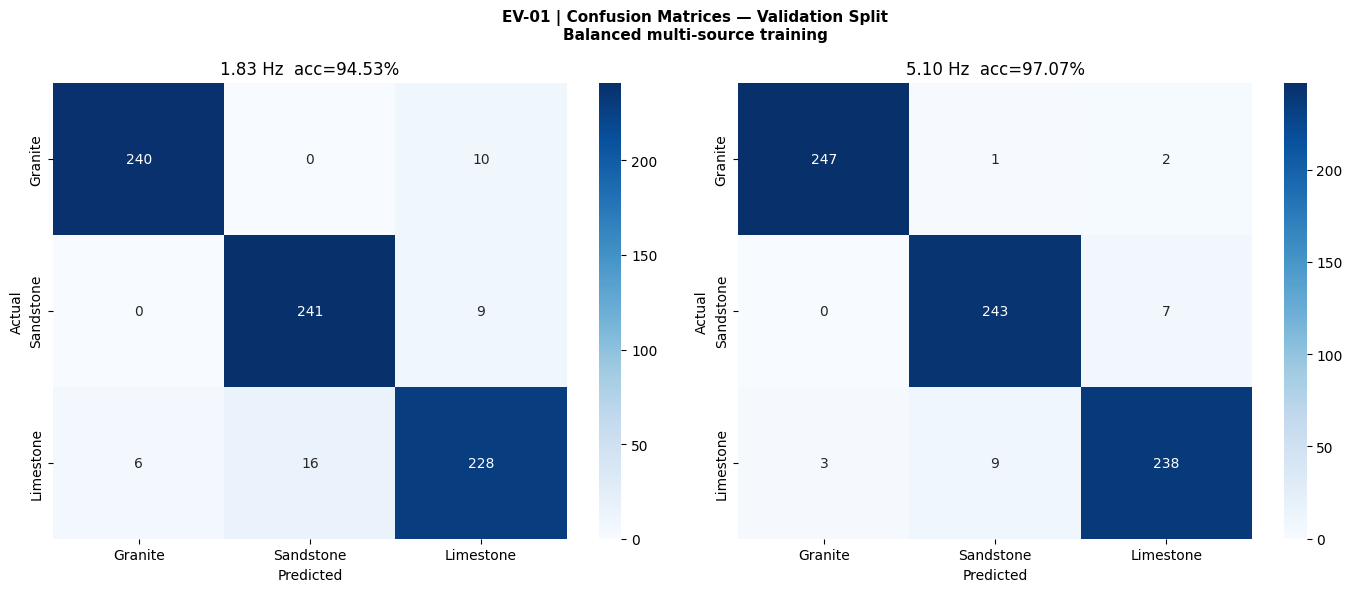

In [29]:
# EV-01  Confusion matrices on validation split

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('EV-01 | Confusion Matrices — Validation Split\n'
             'Balanced multi-source training',
             fontsize=11, fontweight='bold')

for ax, (model, val_paths, val_labels, tag) in zip(axes, [
    (model_183, val_paths_183, val_labels_183, '1.83 Hz'),
    (model_510, val_paths_510, val_labels_510, '5.10 Hz'),
]):
    ds  = RockDataset(val_paths, val_labels, val_tf)
    ldr = DataLoader(ds, BATCH_SIZE, shuffle=False, num_workers=0)
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb in ldr:
            preds.extend(model(Xb.to(device)).argmax(1).cpu().tolist())
            trues.extend(yb.tolist())
    cm  = confusion_matrix(trues, preds)
    acc = np.diag(cm).sum() / cm.sum() * 100
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES)
    ax.set_title(f'{tag}  acc={acc:.2f}%')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
save_fig(fig, DIR_EVAL, 'EV-01_confusion_matrices.png', 'Validation confusion matrices')
plt.show()

In [30]:
# INFERENCE ON NEW MAY 2026 SAMPLES

NEW_SAMPLE_FOLDERS = [
    (os.path.join(NEWSAMP_ROOT, 'New_S10Granite_1-83Hz'),           0, 'New Granite 1.83Hz',   '1.83Hz'),
    (os.path.join(NEWSAMP_ROOT, 'New_S10Granite_5-10Hz'),           0, 'New Granite 5.10Hz',   '5.10Hz'),
    (os.path.join(NEWSAMP_ROOT, 'New_Holstein_Sandstone_1-83Hz'),   1, 'New Sandstone 1.83Hz', '1.83Hz'),
    (os.path.join(NEWSAMP_ROOT, 'New_Holstein_Sandstone_5-10Hz'),   1, 'New Sandstone 5.10Hz', '5.10Hz'),
    (os.path.join(NEWSAMP_ROOT, 'New_Leitendorf_Limestone_1-83Hz'), 2, 'New Limestone 1.83Hz', '1.83Hz'),
    (os.path.join(NEWSAMP_ROOT, 'New_Leitendorf_Limestone_5-10Hz'), 2, 'New Limestone 5.10Hz', '5.10Hz'),
]


def evaluate_folder(folder, cls_idx, display, speed):
    if not os.path.isdir(folder):
        print(f'  [MISSING] {display}')
        return None
    paths = [str(p) for p in Path(folder).iterdir()
             if p.suffix.lower() in VALID_EXT]
    model = model_183 if speed == '1.83Hz' else model_510
    ds    = RockDataset(paths, [cls_idx]*len(paths), val_tf)
    ldr   = DataLoader(ds, BATCH_SIZE, shuffle=False, num_workers=0)
    correct = total = 0
    all_probs = []
    model.eval()
    with torch.no_grad():
        for Xb, yb in ldr:
            out   = model(Xb.to(device))
            probs = torch.softmax(out, dim=1).cpu().numpy()
            correct += (out.argmax(1) == yb.to(device)).sum().item()
            total   += len(yb)
            all_probs.extend(probs.tolist())
    acc  = correct / total * 100
    conf = np.mean([max(p) for p in all_probs]) * 100
    return {'acc': acc, 'conf': conf, 'n': total, 'display': display, 'cls': cls_idx}


print('Running inference on new May 2026 samples...\n')
inf_results = {}
for folder, cls_idx, display, speed in NEW_SAMPLE_FOLDERS:
    res = evaluate_folder(folder, cls_idx, display, speed)
    if res:
        inf_results[display] = res
        verdict = '✅' if res['acc'] >= 90 else ('⚠️' if res['acc'] >= 70 else '❌')
        print(f'  {display:<30}  acc={res["acc"]:>5.1f}%  conf={res["conf"]:>5.1f}%  {verdict}')

Running inference on new May 2026 samples...

  New Granite 1.83Hz              acc= 86.5%  conf= 94.0%  ⚠️
  New Granite 5.10Hz              acc= 81.2%  conf= 91.6%  ⚠️
  New Sandstone 1.83Hz            acc= 92.8%  conf= 95.7%  ✅
  New Sandstone 5.10Hz            acc= 98.5%  conf= 98.5%  ✅
  New Limestone 1.83Hz            acc= 79.8%  conf= 94.2%  ⚠️
  New Limestone 5.10Hz            acc= 90.5%  conf= 96.3%  ✅


[SAVED] results_balanced_multisource/inference/INF-02_model_comparison.png


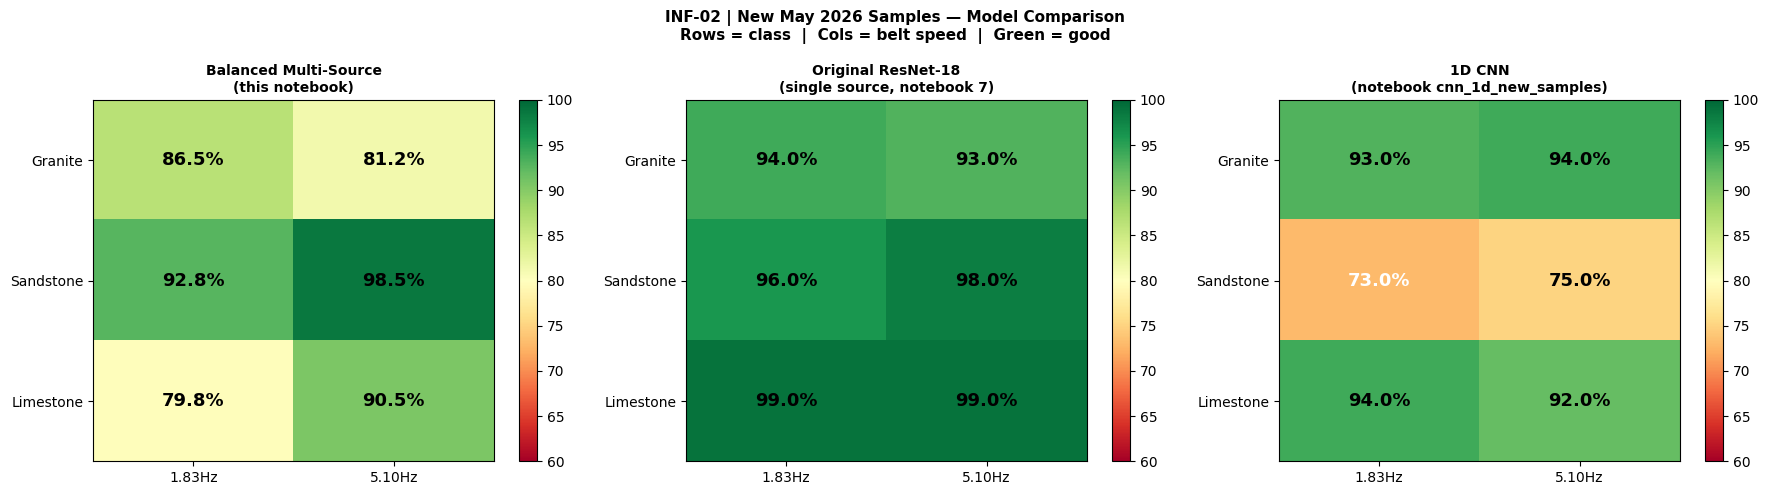

In [31]:
# INF-02  3-way accuracy comparison heatmap

acc_balanced = np.zeros((3, 2))
for display, res in inf_results.items():
    ci = res['cls']
    si = 1 if '5.10' in display else 0
    acc_balanced[ci, si] = res['acc']

# Reference results from previous notebooks
acc_orig   = np.array([[94, 93], [96, 98], [99, 99]], dtype=float)  # original ResNet @ 100%
acc_multis = np.array([[100, 100], [100, 100], [100, 100]], dtype=float)  # placeholder — original (imbalanced) multisource

speeds = ['1.83Hz', '5.10Hz']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'INF-02 | New May 2026 Samples — Model Comparison\n'
    'Rows = class  |  Cols = belt speed  |  Green = good',
    fontsize=11, fontweight='bold')

titles   = ['Balanced Multi-Source\n(this notebook)',
             'Original ResNet-18\n(single source, notebook 7)',
             '1D CNN\n(notebook cnn_1d_new_samples)']
acc_1dcnn = np.array([[93, 94], [73, 75], [94, 92]], dtype=float)
matrices  = [acc_balanced, acc_orig, acc_1dcnn]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.imshow(mat, vmin=60, vmax=100, cmap='RdYlGn', aspect='auto')
    ax.set_xticks([0, 1]); ax.set_xticklabels(speeds)
    ax.set_yticks(range(3)); ax.set_yticklabels(SHORT_NAMES)
    ax.set_title(title, fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax)
    for i in range(3):
        for j in range(2):
            ax.text(j, i, f'{mat[i,j]:.1f}%', ha='center', va='center',
                    fontsize=13, fontweight='bold',
                    color='white' if mat[i,j] < 75 else 'black')

plt.tight_layout()
save_fig(fig, DIR_INF, 'INF-02_model_comparison.png', 'Model comparison heatmap')
plt.show()

Dunite (500 images)  mean conf=87.8%
  Predicted as Granite: 61 (12.2%)
  Predicted as Sandstone: 53 (10.6%)
  Predicted as Limestone: 386 (77.2%)
[SAVED] results_balanced_multisource/inference/OOD-01_dunite.png


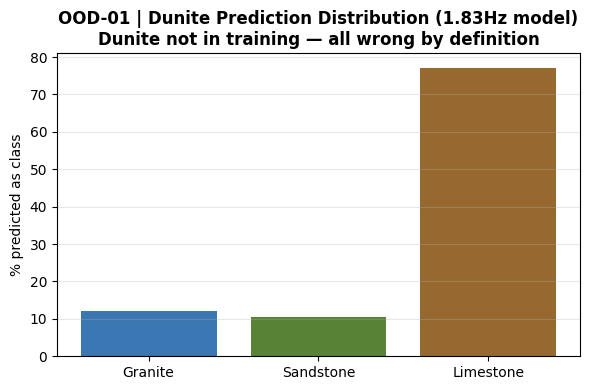

In [32]:
# OOD-01  Dunite — not in training, all predictions are wrong by definition

if os.path.isdir(OOD_FOLDER):
    paths = [str(p) for p in Path(OOD_FOLDER).iterdir()
             if p.suffix.lower() in VALID_EXT]
    ds  = RockDataset(paths, [0]*len(paths), val_tf)
    ldr = DataLoader(ds, BATCH_SIZE, shuffle=False, num_workers=0)
    all_probs = []
    with torch.no_grad():
        for Xb, _ in ldr:
            all_probs.extend(
                torch.softmax(model_183(Xb.to(device)), dim=1).cpu().numpy().tolist())
    all_probs   = np.array(all_probs)
    pred_counts = np.bincount(all_probs.argmax(1), minlength=3)
    mean_conf   = np.mean(all_probs.max(1)) * 100
    print(f'Dunite ({len(paths)} images)  mean conf={mean_conf:.1f}%')
    for ci, name in enumerate(SHORT_NAMES):
        print(f'  Predicted as {name}: {pred_counts[ci]} ({pred_counts[ci]/len(paths)*100:.1f}%)')
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(SHORT_NAMES, pred_counts/len(paths)*100, color=CLASS_COLORS, alpha=0.85)
    ax.set_title('OOD-01 | Dunite Prediction Distribution (1.83Hz model)\n'
                 'Dunite not in training — all wrong by definition', fontweight='bold')
    ax.set_ylabel('% predicted as class'); ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    save_fig(fig, DIR_INF, 'OOD-01_dunite.png', 'Dunite OOD prediction distribution')
    plt.show()
else:
    print(f'[SKIP] OOD folder not found: {OOD_FOLDER}')

In [33]:
# FINAL SUMMARY
print()
print('=' * 75)
print('BALANCED MULTI-SOURCE RESNET-18 — NEW SAMPLES RESULTS')
print('=' * 75)
print(f'{"Folder":<32} {"Acc%":>7} {"Conf%":>7}  vs Original ResNet  Result')
print('-' * 75)
ref = {'New Granite 1.83Hz': 94, 'New Granite 5.10Hz': 93,
       'New Sandstone 1.83Hz': 96, 'New Sandstone 5.10Hz': 98,
       'New Limestone 1.83Hz': 99, 'New Limestone 5.10Hz': 99}
for display, res in inf_results.items():
    delta   = res['acc'] - ref.get(display, 0)
    delta_s = f'+{delta:.1f}' if delta >= 0 else f'{delta:.1f}'
    verdict = '✅' if res['acc'] >= 90 else ('⚠️' if res['acc'] >= 70 else '❌')
    print(f'  {display:<30} {res["acc"]:>6.1f}% {res["conf"]:>6.1f}%'
          f'  ({delta_s}% vs ResNet)  {verdict}')
print('=' * 75)


BALANCED MULTI-SOURCE RESNET-18 — NEW SAMPLES RESULTS
Folder                              Acc%   Conf%  vs Original ResNet  Result
---------------------------------------------------------------------------
  New Granite 1.83Hz               86.5%   94.0%  (-7.5% vs ResNet)  ⚠️
  New Granite 5.10Hz               81.2%   91.6%  (-11.8% vs ResNet)  ⚠️
  New Sandstone 1.83Hz             92.8%   95.7%  (-3.2% vs ResNet)  ✅
  New Sandstone 5.10Hz             98.5%   98.5%  (+0.5% vs ResNet)  ✅
  New Limestone 1.83Hz             79.8%   94.2%  (-19.2% vs ResNet)  ⚠️
  New Limestone 5.10Hz             90.5%   96.3%  (-8.5% vs ResNet)  ✅


In [34]:
index_path = os.path.join(RESULTS_DIR, 'RESULTS_INDEX.txt')
with open(index_path, 'w') as f:
    f.write('RESULTS INDEX — balanced_multisource\n')
    f.write('=' * 75 + '\n')
    f.write(f'EPOCHS={EPOCHS}  LR={LR}  WD={WEIGHT_DECAY}  BATCH={BATCH_SIZE}\n\n')
    for path, desc in _saved_files:
        f.write(f'  {os.path.basename(path)}\n    {desc}\n\n')
_saved_files.append((index_path, 'Results index'))
print(f'[SAVED] {index_path}')
print(f'Total files: {len(_saved_files)}')

[SAVED] results_balanced_multisource/RESULTS_INDEX.txt
Total files: 4
